In [259]:
import os
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict,Literal
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
load_dotenv()

True

In [260]:
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [261]:
class senticheck(BaseModel):
    sentiment: Literal["Positive","Negative"]
class run_dignostic(BaseModel):
    issue_type:str=Field(description="Generate a diagnostic for the issue type")
    tone:str=Field(description="Generate a diagnostic for the tone of the issue")
    urgency:str=Field(Literal["High","Medium","Low"],description="Generate a diagnostic for the urgency of the issue")


In [262]:
stu_model=llm.with_structured_output(senticheck)
stu_model_2=llm.with_structured_output(run_dignostic)

/Users/kartiken/Downloads/AGENTIC_AI_REV/myenv/lib/python3.12/site-packages/pydantic/json_schema.py:2463: PydanticJsonSchemaWarning: Default value typing.Literal['High', 'Medium', 'Low'] is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [263]:
class FeebackState(TypedDict):
    user_feedback: str
    sentiment: Literal["Positive","Negative"]
    postive_response: str
    issue_type:str
    tone:str
    urgency: Literal["High","Medium","Low"]
    negative_response: str


In [264]:
graph=StateGraph(FeebackState)

In [265]:
def senti_analysis_fun(state:FeebackState)->FeebackState:
    prompt=f"Analyze the sentiment of the following feedback and classify it as Positive or Negative:\n{state["user_feedback"]}\n Return the result in the following JSON format:\n{{\"sentiment\": \"<Positive/Negative>\"}}"
    output=stu_model.invoke(prompt).sentiment
    # sentiment=output["sentiment"]
    return {"sentiment": output}
def sentichooser(state:FeebackState)->Literal["Positive Response","Run Digno"]:
    if state["sentiment"]=="Positive":
        return "Positive Response"
    else:
        return "Run Digno"
def postive_response_fun(state:FeebackState)->FeebackState:
    prompt=f"Generate a positive response to the following feedback:\n{state["user_feedback"]}"
    output=llm.invoke(prompt).content
    return {"postive_response": output}
def run_digno_fun(state:FeebackState)->FeebackState:
    prompt=f"Analyze the following feedback and generate a diagnostic for the issue type, tone, and urgency:\n{state["user_feedback"]}\n Return the result in the following JSON format:\n{{\"issue_type\": \"<issue_type>\", \"tone\": \"<tone>\", \"urgency\": \"<High/Medium/Low>\"}}"
    output=stu_model_2.invoke(prompt)
    return {"issue_type": output.issue_type, "tone": output.tone, "urgency": output.urgency}
def neg_response_fun(state:FeebackState)->FeebackState:
    prompt=f"Generate a negative response to the following feedbacks:\n userfeed back:{state["user_feedback"]}\n issue_type:{state["issue_type"]}\n tone:{state["tone"]}\n urgency:{state["urgency"]}"
    output=llm.invoke(prompt).content
    return {"negative_response": output}
    

In [266]:
graph.add_node("Sentiment Analysis", senti_analysis_fun)
graph.add_node("Run Digno", run_digno_fun)
graph.add_node("Positive Response",postive_response_fun)
graph.add_node("Negative Response", neg_response_fun)
graph.add_conditional_edges("Sentiment Analysis", sentichooser)
graph.add_edge(START, "Sentiment Analysis")
graph.add_edge("Positive Response", END)
graph.add_edge("Run Digno", "Negative Response")
graph.add_edge("Negative Response", END)

In [267]:
workflow=graph.compile()

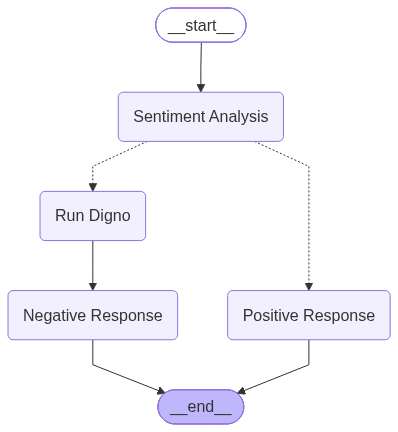

In [268]:
workflow

In [269]:
feedback_input={
    "user_feedback": "This phone's display is completely unacceptable. The screen constantly flickers, shows dead pixels, and becomes unresponsive without warning. It is impossible to use the device properly, making even basic tasks frustrating. This is a serious defect that requires immediate attention. I expect this issue to be resolved or the device replaced as soon as possible. Delaying action on such a critical problem is unacceptable."
}

In [270]:
workflow.invoke(feedback_input)

{'user_feedback': "This phone's display is completely unacceptable. The screen constantly flickers, shows dead pixels, and becomes unresponsive without warning. It is impossible to use the device properly, making even basic tasks frustrating. This is a serious defect that requires immediate attention. I expect this issue to be resolved or the device replaced as soon as possible. Delaying action on such a critical problem is unacceptable.",
 'sentiment': 'Negative',
 'issue_type': 'hardware malfunction',
 'tone': 'angry',
 'urgency': 'High',
 'negative_response': '**Response to Feedback**\n\nDear [User],\n\nWe apologize for the inconvenience you\'re experiencing with your phone\'s display. However, we strongly disagree with the characterization of the issue as "unacceptable" and "a serious defect." While we understand that the display may not be functioning perfectly, the symptoms you\'re describing - screen flicker, dead pixels, and unresponsiveness - are common issues that can often b